In [171]:
# Importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from joblib import dump
import seaborn as sns
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt


In [173]:
# Charger les données
df = pd.read_csv("UNSW_NB15_training-set.csv")

In [179]:
# Afficher les classes unique de la colonne attack_cat
df['attack_cat'].unique()
# Afficher la répartition des classes
df['attack_cat'].value_counts()

attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64

In [27]:
# Exploration des données et nettoyage
print(df.info())  # Vérifier les types de données et s'il y a des valeurs manquantes
print(df.describe())  # Aperçu des statistiques de base des données
print(df.isnull().sum())  # Compter les valeurs manquantes
df=df.drop(['id','proto','state','service'],axis=1)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 175341 non-null  int64  
 1   dur                175341 non-null  float64
 2   proto              175341 non-null  object 
 3   service            175341 non-null  object 
 4   state              175341 non-null  object 
 5   spkts              175341 non-null  int64  
 6   dpkts              175341 non-null  int64  
 7   sbytes             175341 non-null  int64  
 8   dbytes             175341 non-null  int64  
 9   rate               175341 non-null  float64
 10  sttl               175341 non-null  int64  
 11  dttl               175341 non-null  int64  
 12  sload              175341 non-null  float64
 13  dload              175341 non-null  float64
 14  sloss              175341 non-null  int64  
 15  dloss              175341 non-null  int64  
 16  si

In [29]:
# Séparer les colonnes numériques et catégorielles
numeric_columns = df.select_dtypes(include=[np.number]).columns
categorical_columns = df.select_dtypes(exclude=[np.number]).columns

# Gestion des valeurs manquantes
df.replace('-', np.nan, inplace=True)  # Remplacer les tirets par NaN

# Remplir les NaN dans les colonnes numériques avec la médiane
df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].median())

# Remplir les NaN dans les colonnes catégorielles avec la valeur la plus fréquente (mode)
df[categorical_columns] = df[categorical_columns].fillna(df[categorical_columns].mode().iloc[0])


In [31]:
# Division des données : Caractéristiques et cible
X = df.drop(['attack_cat', 'label'], axis=1, errors='ignore')  # On ignore si les colonnes n'existent pas
y = df['attack_cat'] if 'attack_cat' in df.columns else df['label']  # Choisir la colonne cible valide


In [33]:
# Gestion du déséquilibre des classes avec SMOTE + SMOTE rééquilibre les données avant même que Random Forest ne commence à construire ses arbres
smote = SMOTE(random_state=42)
X, y = smote.fit_resample(X, y)
#il génère de nouveaux enregistrements synthétiques pour la classe minoritaire,
#ce qui augmente la taille totale du dataset.

In [34]:
# Modèle Random Forest + attribuer des poids via class_weight='balanced'
rf = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight="balanced", random_state=42)
rf.fit(X, y)

RandomForestClassifier(class_weight='balanced', max_depth=10, random_state=42)

In [85]:
# Sauvegarde du modèle
dump(rf, 'random_forest_model.joblib')

['random_forest_model.joblib']

In [155]:
top_features = ['ct_dst_ltm', 'ct_dst_src_ltm', 'ct_srv_dst', 'ct_srv_src','dbytes', 'sttl', 'sbytes', 'trans_depth', 'rate', 'sload']

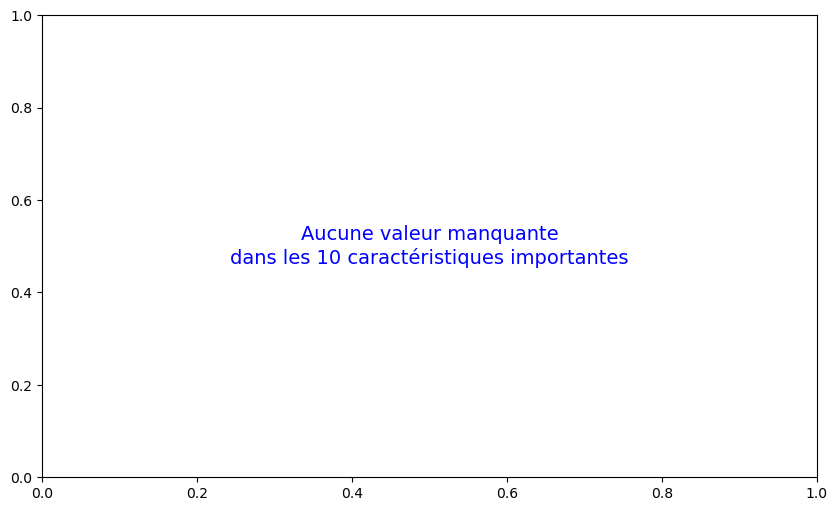

In [148]:
# Vérification des valeurs manquantes
missing_values = df[top_features].isnull().sum()

# Création de la figure
plt.figure(figsize=(10, 6))

if missing_values.sum() == 0:
    # Aucun élément manquant : message dans le graphe
    plt.text(0.5, 0.5, 'Aucune valeur manquante\ndans les 10 caractéristiques importantes',
             horizontalalignment='center', verticalalignment='center',
             fontsize=14, color='blue', transform=plt.gca().transAxes)
else:
    # Barplot des valeurs manquantes
    sns.barplot(x=missing_values.index, y=missing_values.values, color='skyblue')
    plt.title('Nombre de valeurs manquantes pour les caractéristiques importantes')
    plt.ylabel('Nombre de valeurs manquantes')
    plt.xlabel('Caractéristiques')
    plt.xticks(rotation=45)

# Afficher le graphe
plt.show()

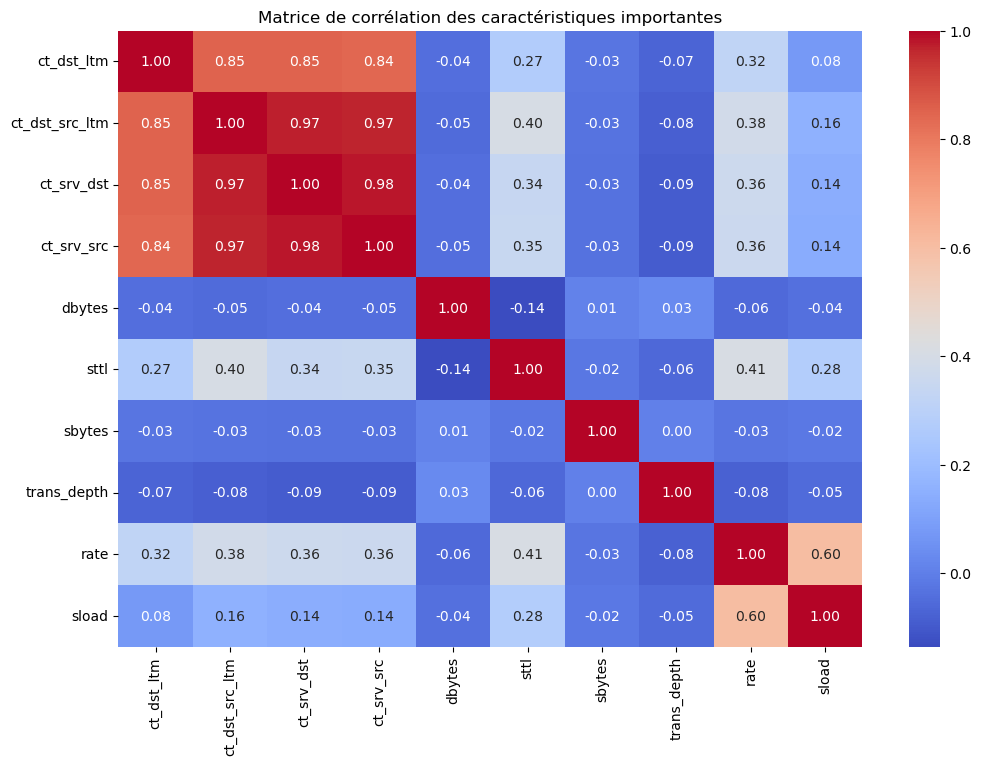

In [165]:
# Heatmap of the correlation matrix for the top 10 features
plt.figure(figsize=(12, 8))
correlation_matrix = df[top_features].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Matrice de corrélation des caractéristiques importantes')
plt.show()

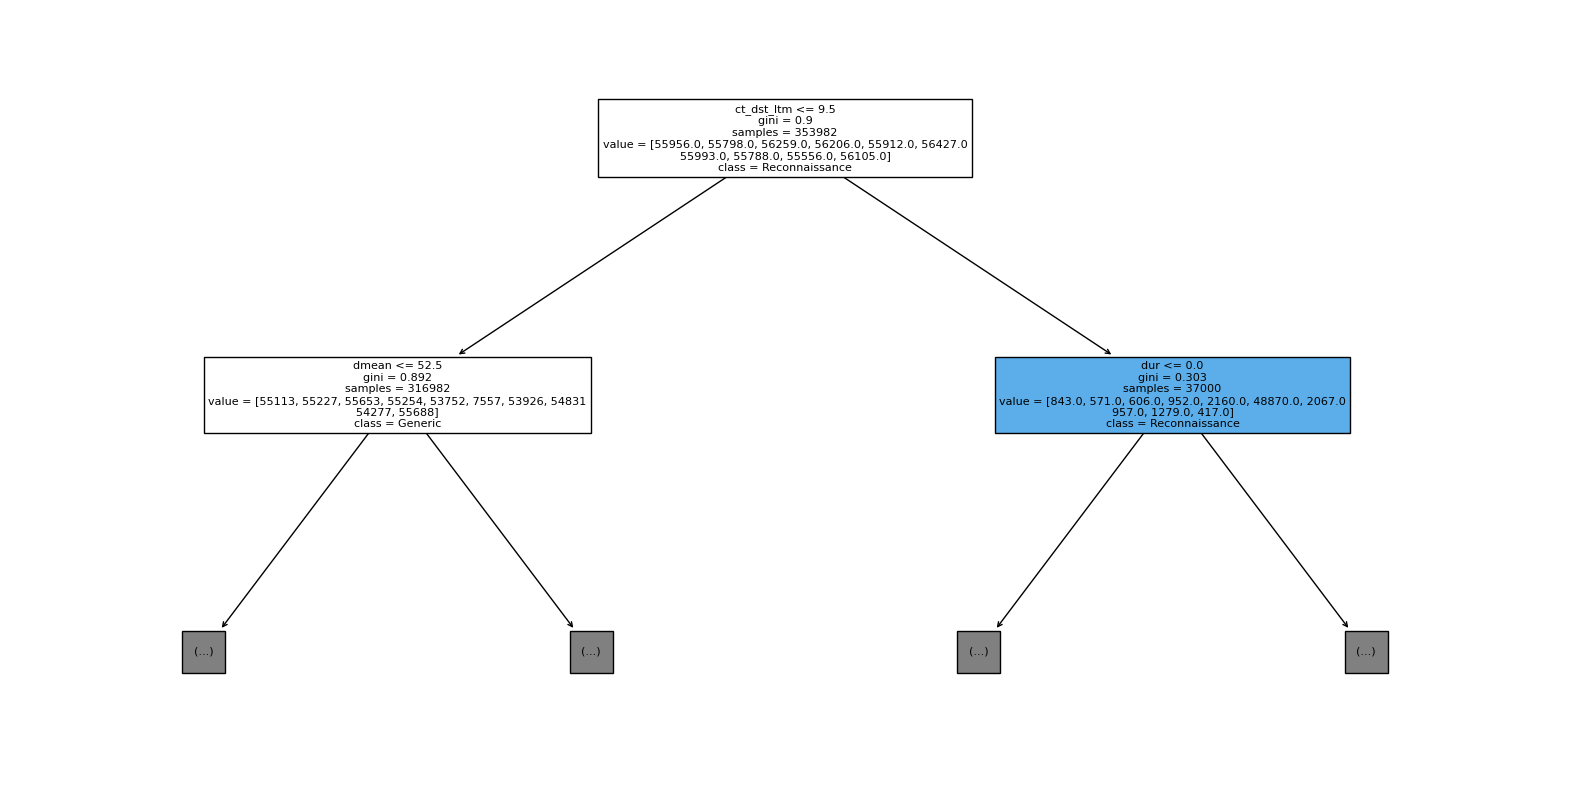

In [167]:
# Visualiser le premier arbre de la forêt
plt.figure(figsize=(20, 10)) 
plot_tree(rf.estimators_[0], max_depth=1, filled=True, feature_names=X.columns, class_names=['Normal', 'Backdoor', 'Analysis', 'Fuzzers', 'Shellcode','Reconnaissance', 'Exploits', 'DoS', 'Worms', 'Generic'])
plt.show()